# Shipment Problem: Optimization Walkthrough
Welcome! In this notebook, we will model and solve the multi-warehouse shipment optimization problem using Gurobi.

- We have 10 warehouses and 859 customers.
- Each of 15 products has a limited stock at each warehouse.
- Each customer pre-orders a certain amount of each product.
- The goal: **Minimize total shipment cost**, where cost is proportional to distance shipped.

# Shipment Problem: Optimization Walkthrough

Welcome! In this notebook, we will model and solve the multi-warehouse shipment optimization problem using Gurobi.

The goal of this optimization problem is to determine the most cost-effective way to ship products from warehouses to customers to meet their pre-orders. We want to minimize the total shipment cost, which is directly proportional to the distance the products are shipped.


### Colab Setup
This cell is only for colab setup. On your own machine, you don't have to install gurobipy or or setup the license everytime.

In [ ]:
#pip install gurobipy --quiet

In [ ]:
# 以下为 Colab 专用：在 Colab 中取消注释即可挂载 Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
pass  # 本地运行无需挂载 Drive，直接跳过

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Set the working directory
import os

# Colab 路径（在 Colab 中可取消下面两行注释并注释掉“本地运行”部分）
# working_path = "/content/drive/MyDrive/Large Data LP Example | Shipment Problem" # Replace with your own path
# os.environ['GRB_LICENSE_FILE'] = 'gurobi.lic'

# 本地运行：先尝试当前目录，若无数据文件则尝试常见 LP5 路径
working_path = os.getcwd()
if not os.path.isfile(os.path.join(working_path, 'shipment_data.xlsx')):
    for _d in [os.path.join(os.getcwd(), 'Opt Models', 'LP5'), os.path.join(os.getcwd(), 'LP5')]:
        if os.path.isdir(_d) and os.path.isfile(os.path.join(_d, 'shipment_data.xlsx')):
            working_path = _d
            break
os.chdir(working_path)
# 若本机已配置 Gurobi 许可证（如环境变量 GRB_LICENSE_FILE），可取消下一行注释
# os.environ['GRB_LICENSE_FILE'] = 'gurobi.lic'

## Load Libraries and Explore Data


In [1]:
from gurobipy import Model, GRB, quicksum
import pandas as pd
import numpy as np

In [3]:
#Load your data

xls = pd.ExcelFile('shipment_data.xlsx')
pre_order_matrix = pd.read_excel(xls,'Pre-Order Matrix', index_col =0)
stock_matrix = pd.read_excel(xls,'Stock Matrix', index_col =0)
distance_matrix = pd.read_excel(xls,'Distance Matrix', index_col =0)

### Data Overview

We are provided with three key datasets to define the problem:

- **`pre_order_matrix`**: This matrix details the pre-ordered quantity of each product by each customer. Rows represent customers, and columns represent products.
- **`stock_matrix`**: This matrix shows the available stock of each product at each warehouse. Rows represent warehouses, and columns represent products.
- **`distance_matrix`**: This matrix contains the shipment cost (or distance, assuming cost is proportional to distance) between each warehouse and each customer. Rows represent warehouses, and columns represent customers.

In [4]:
pre_order_matrix.head()

,Product1,Product2,Product3,Product4,Product5,Product6,Product7,Product8,Product9,Product10,Product11,Product12,Product13,Product14,Product15
C1,0,4,5,0,3,4,4,1,5,5,1,3,2,3,1
C2,2,2,5,4,5,3,0,4,1,0,0,3,2,5,5
C3,3,2,3,4,0,2,3,1,5,3,1,5,1,3,4
C4,1,4,2,5,5,1,5,1,5,5,4,3,4,0,0
C5,5,2,5,5,4,1,0,1,1,2,0,2,5,0,1


In [5]:
stock_matrix.head()

,Product1,Product2,Product3,Product4,Product5,Product6,Product7,Product8,Product9,Product10,Product11,Product12,Product13,Product14,Product15
W1,501,172,608,1007,822,28,1234,191,926,1200,159,608,1408,898,924
W2,1401,1005,93,778,143,980,26,591,721,318,825,107,1199,1214,0
W3,280,943,1098,333,509,1385,306,806,1358,1380,573,106,1327,1053,643
W4,740,807,392,7,335,1464,1384,721,514,489,1074,1001,474,1459,741
W5,231,365,659,1095,449,1094,780,425,1150,620,255,1326,136,994,195


In [26]:
distance_matrix.head()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,...,C850,C851,C852,C853,C854,C855,C856,C857,C858,C859
W1,347,279,402,864,423,546,289,958,379,317,...,419,948,696,588,189,163,154,605,731,97
W2,399,628,112,598,446,36,108,549,145,592,...,232,425,949,231,62,123,453,18,935,70
W3,984,176,532,576,796,149,141,206,257,275,...,164,567,272,729,138,728,680,706,873,585
W4,628,388,714,321,105,739,628,596,527,206,...,255,688,708,812,596,835,19,786,275,947
W5,281,781,141,550,155,522,272,812,629,155,...,938,330,713,264,756,829,505,945,587,982


In [6]:
warehouses = stock_matrix.index.tolist()
products = stock_matrix.columns.tolist()
customers = pre_order_matrix.index.tolist()

num_warehouses= len(warehouses)
num_products = len(products)
num_customers= len(customers )

print("Number of customers: ", num_customers)
print("Number of products: ", num_products)
print("Number of warehouses: ", num_warehouses)

Number of customers:  859
Number of products:  15
Number of warehouses:  10


In [7]:
num_warehouses* num_products * num_customers

128850

## Set Up Gurobi Model
Now let's set up the shipment optimization problem!

In [8]:
#Initialize model

m = Model("shipment")

Set parameter Username
Academic license - for non-commercial use only - expires 2026-09-08


### Decision Variables

We define $x_{pwc}$ as the number of units of product $p$ shipped from warehouse $w$ to customer $c$.


In [9]:
x = {}
# Define the decision variables. x[p, w, c] represents the number of units of product 'p'
# that are shipped from warehouse 'w' to customer 'c'.
# The variable type is set to GRB.INTEGER because we can only ship whole units of products.
for p in products:
    for w in warehouses:
        for c in customers:
            x[p,w,c] = m.addVar(vtype = GRB.CONTINUOUS, lb=0,  name= f"ship_{p,w,c}")

### Optimization Objective

The primary objective of this optimization problem is to **minimize the total shipment cost**. This cost is calculated by summing the product of the number of units shipped for each product from each warehouse to each customer and the corresponding distance (cost) from the `distance_matrix`.

In [10]:
# Set the objective function. The goal is to minimize the total shipment cost.
# The total cost is the sum of the cost of shipping each product from each warehouse to each customer.
# The cost for each shipment is the number of units shipped (x[p,w,c]) multiplied by the distance (cost)
# between the warehouse and the customer (distance_matrix.loc[w,c]).
m.setObjective(quicksum(x[p,w,c]*distance_matrix.loc[w,c]
               for p in products for w in warehouses for c in customers),
               GRB.MINIMIZE)

In [11]:
m.update()

m.write("shipment.lp")

In [33]:
with open('shipment.lp', 'r') as file:
     print(file.read())

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



### Constraints Overview

**1. Stock constraints:**  
Total units shipped of product $p$ from warehouse $w$ ≤ stock at warehouse.

**2. Demand constraints:**  
Each customer's pre-order must be fulfilled exactly.


In [12]:
#Constraints

# Stock constraints: Ensure that the total number of units of product 'p' shipped from warehouse 'w'
# to all customers does not exceed the available stock of product 'p' at warehouse 'w' (stock_matrix.loc[w,p]).
stock_const = m.addConstrs((quicksum(x[p,w,c] for c in customers) <= stock_matrix.loc[w,p]
                            for w in warehouses for p in products), name=f"Stock_{p,w}")

In [13]:
# Demand constraints: Ensure that the total number of units of product 'p' received by customer 'c'
# from all warehouses exactly matches the pre-ordered quantity of product 'p' by customer 'c' (pre_order_matrix.loc[c,p]).
demand_const = m.addConstrs((quicksum(x[p,w,c] for w in warehouses) == pre_order_matrix.loc[c,p]
                            for c in customers for p in products), name=f"Demand_{c,p}")

### Optimization Parameters

`GRB.Param.PoolSearchMode` [Documentation](https://docs.gurobi.com/projects/optimizer/en/current/reference/parameters.html#poolsearchmode)
* The `PoolSearchMode` parameter controls how the MIP solver searches for multiple solutions.
* Default (0): Solver stops after finding the best solution; extra solutions found are incidental.
* Non-default (1 or 2): Solver searches for multiple solutions (number set by PoolSolutions).
    * 1: Finds multiple solutions without guaranteeing the best;
    * 2: Finds the n best solutions (higher solve time).

`GRB.Param.PoolSolutions` [Documentation](https://docs.gurobi.com/projects/optimizer/en/current/reference/parameters.html#poolsolutions)
* `PoolSolutions` sets how many MIP solutions to store (default: 10, min: 1, max: `MAXINT`).
* With `PoolSearchMode=0`, these are incidental solutions; with other modes, it sets the target number of solutions to find (higher values may slow performance).




In [14]:
# Set Gurobi parameters to find and store multiple optimal solutions.
# PoolSearchMode = 2: Instructs Gurobi to find the number of requested solutions.
m.setParam(GRB.Param.PoolSearchMode, 2)

# PoolSolutions = 10: Specifies the maximum number of optimal solutions to store.
m.setParam(GRB.Param.PoolSolutions, 10)  # Adjust this number based on how many solutions you'd like to retrieve

Set parameter PoolSearchMode to value 2


In [15]:
# 若报错 GurobiError: Model too large for size-limited license，表示当前 Gurobi 为规模限制版，需使用非限制许可证或在 Colab 用学术许可证运行
m.optimize()

Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i9-13900H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 13035 rows, 128850 columns and 257700 nonzeros
Model fingerprint: 0xe6d2c714
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+03]
Presolve time: 0.13s
Presolved: 10899 rows, 106793 columns, 213586 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.00s

Barrier statistics:
 AA' NZ     : 1.068e+05
 Factor NZ  : 1.236e+05 (roughly 50 MB of memory)
 Factor Ops : 1.500e+06 (less than 1 second per iteration)
 Threads    : 12

Barrier performed 0 iterations in 0.21 seconds (0.10 work units)
Barrier solve interrupted - model solved by another algorithm


Solved with dual simplex
It

### Interpreting the Optimal Shipment Plan

After optimizing the model, Gurobi provides the optimal values for our decision variables, $x_{pwc}$. These values represent the number of units of product $p$ that should be shipped from warehouse $w$ to customer $c$ to achieve the minimum total shipment cost while satisfying all stock and demand constraints.

The output below lists each specific shipment where the quantity shipped is greater than zero. This provides a detailed breakdown of the optimal shipping plan, showing exactly how each customer's pre-order is fulfilled by shipments from various warehouses.

In [16]:
# Display the results for each combination
if m.status == GRB.OPTIMAL:
    solution = m.getAttr('x', x)
    for p in products:
        for w in warehouses:
            for c in customers:
                if solution[p, w, c] > 0:
                    print(f"Ship {solution[p, w, c]} units of {p} from {w} to {c}")


Ship 2.0 units of Product1 from W1 to C16
Ship 3.0 units of Product1 from W1 to C23
Ship 5.0 units of Product1 from W1 to C24
Ship 4.0 units of Product1 from W1 to C31
Ship 4.0 units of Product1 from W1 to C52
Ship 3.0 units of Product1 from W1 to C78
Ship 3.0 units of Product1 from W1 to C87
Ship 2.0 units of Product1 from W1 to C88
Ship 2.0 units of Product1 from W1 to C93
Ship 4.0 units of Product1 from W1 to C111
Ship 2.0 units of Product1 from W1 to C119
Ship 3.0 units of Product1 from W1 to C126
Ship 4.0 units of Product1 from W1 to C156
Ship 2.0 units of Product1 from W1 to C177
Ship 1.0 units of Product1 from W1 to C193
Ship 2.0 units of Product1 from W1 to C194
Ship 3.0 units of Product1 from W1 to C205
Ship 1.0 units of Product1 from W1 to C218
Ship 3.0 units of Product1 from W1 to C227
Ship 2.0 units of Product1 from W1 to C246
Ship 3.0 units of Product1 from W1 to C264
Ship 4.0 units of Product1 from W1 to C275
Ship 2.0 units of Product1 from W1 to C280
Ship 3.0 units of Pr

## Visualizing Aggregated Shipments with a Heatmap

While the detailed shipment plan is informative, it can be challenging to grasp the overall shipping patterns from a long list. To get a clearer picture of which warehouses are major suppliers for which products, we can aggregate the shipment data.




### Heatmap Data preparation
First, let's use the below code to create a pandas DataFrame from the optimal solution, summarizing the total units of each product shipped from each warehouse. This aggregated data is then transformed into a pivot table, with warehouses as rows and products as columns.

In [17]:
# Assuming m is your Gurobi model and 'x' is your decision variable (3D array of variables)
if m.status == GRB.OPTIMAL:
    # Retrieve decision variables and their solution values
    solution = m.getAttr('x', x)

    # Initialize dictionary to hold the aggregated shipments from each warehouse and product combination
    shipments = {}

    # Loop over all decision variables
    for p in products:
        for w in warehouses:
            total_shipped = 0
            for c in customers:
                # Access the solution value using the .X attribute
                if x[p, w, c].X > 0:  # Ensure you are accessing the variable correctly
                    total_shipped += x[p, w, c].X

            if total_shipped > 0:
                shipments[(w, p)] = total_shipped

    # Proceed to create DataFrame and pivot table
    results_df = pd.DataFrame.from_records(list(shipments.items()), columns=['Warehouse_Product', 'Shipment'])
    results_df[['Warehouse', 'Product']] = pd.DataFrame(results_df['Warehouse_Product'].tolist(), index=results_df.index)
    results_df.drop(columns=['Warehouse_Product'], inplace=True)

    # Pivot table for heatmap
    pivot_df = results_df.pivot(index='Warehouse', columns='Product', values='Shipment').fillna(0)
    # Define the desired order for warehouses and products
    warehouse_order = [f"W{i}" for i in range(1, 11)]
    product_order = [f"Product{i}" for i in range(1, 16)]

    # Reindex the pivoted DataFrame to enforce these orders
    pivot_df = pivot_df.reindex(index=warehouse_order, columns=product_order, fill_value=0)
    print(pivot_df)


Product    Product1  Product2  Product3  Product4  Product5  Product6  \
Warehouse                                                               
W1            204.0     172.0     229.0     282.0     244.0      28.0   
W2            219.0     225.0      93.0     273.0     143.0     216.0   
W3            249.0     236.0     237.0     282.0     229.0     285.0   
W4            277.0     303.0     301.0       7.0     294.0     317.0   
W5            211.0     236.0     197.0     230.0     193.0     230.0   
W6            183.0     201.0     204.0     197.0     207.0     219.0   
W7            256.0     170.0     229.0     289.0     258.0     160.0   
W8            241.0     229.0     236.0     245.0     213.0     238.0   
W9            178.0     204.0     153.0     243.0     214.0     217.0   
W10           231.0     191.0     226.0     110.0     212.0     236.0   

Product    Product7  Product8  Product9  Product10  Product11  Product12  \
Warehouse                                      

### Heatmap
Now, let's use the pivot table to generate a heatmap.

A heatmap is a powerful visualization tool that uses color intensity to represent the magnitude of a value in a matrix. In this case, the color of each cell will indicate the total quantity of a specific product shipped from a particular warehouse.

This allows for quick identification of the dominant shipping routes and product distributions.

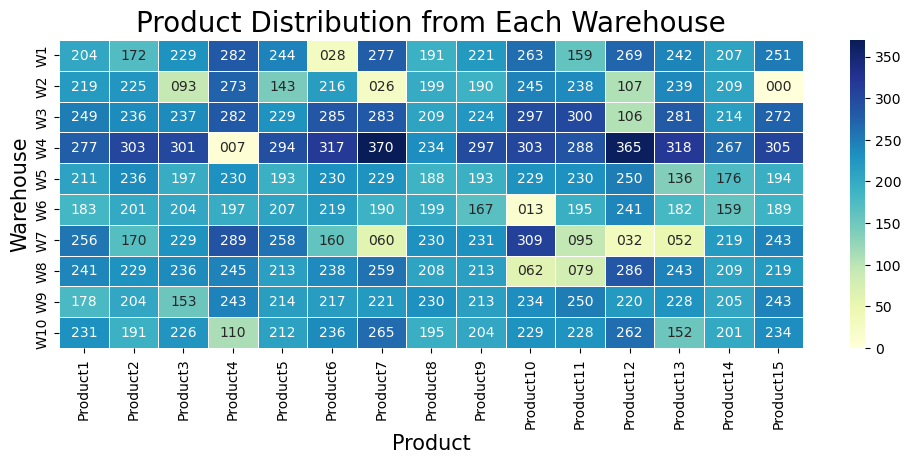

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

def fmt(x):
    return "{:03d}".format(int(x))

plt.figure(figsize=(12, 4))

# Create a 2D array of annotations
annotations = np.vectorize(fmt)(pivot_df.values)

sns.heatmap(pivot_df, cmap='YlGnBu', linewidths=.5, annot=annotations, fmt="", annot_kws={"size": 10})

plt.title('Product Distribution from Each Warehouse', fontsize=20)
plt.xlabel('Product', fontsize=15)
plt.ylabel('Warehouse', fontsize=15)

plt.show()

### Interpreting the Heatmap

The heatmap visually summarizes the aggregated shipment quantities of each product from each warehouse based on the optimal solution.

- **Axes:** The y-axis represents the Warehouses (W1 to W10), and the x-axis represents the Products (Product1 to Product15).
- **Color Intensity:** The color of each cell in the heatmap indicates the volume of shipments for a specific product from a specific warehouse. Darker or more intensely colored cells represent higher shipment quantities, while lighter cells indicate lower quantities. Cells with a value of 0 (meaning no shipments) are typically the lightest color.
- **Annotations:** The numbers annotated within each cell provide the exact total number of units shipped for that warehouse-product combination.

By examining the heatmap, you can quickly identify patterns and insights into the optimal shipping strategy, such as:

- **Warehouse Specialization:** Are certain warehouses primarily shipping specific products?
- **Product Distribution:** Which products are being shipped in large quantities from multiple warehouses?
- **High-Volume Routes:** Which specific warehouse-product combinations have the highest shipment volumes?

This visualization provides a concise and intuitive overview of the complex shipment plan, making it easier to understand the flow of goods in the optimal solution.

## Print Multiple Optimal Solutions

In [41]:
#How to print multiple optimal solutions

num_solutions = m.SolCount
print(f"Found {num_solutions} solutions.")

for i in range(num_solutions):
    m.setParam(GRB.Param.SolutionNumber, i)
    print(f"Solution {i+1}:")
    for v in m.getVars():
        print(f"{v.varName} = {v.x}")

Found 1 solutions.
Solution 1:
ship_('Product1', 'W1', 'C1') = 0.0
ship_('Product1', 'W1', 'C2') = 0.0
ship_('Product1', 'W1', 'C3') = 0.0
ship_('Product1', 'W1', 'C4') = 0.0
ship_('Product1', 'W1', 'C5') = 0.0
ship_('Product1', 'W1', 'C6') = 0.0
ship_('Product1', 'W1', 'C7') = 0.0
ship_('Product1', 'W1', 'C8') = 0.0
ship_('Product1', 'W1', 'C9') = 0.0
ship_('Product1', 'W1', 'C10') = 0.0
ship_('Product1', 'W1', 'C11') = 0.0
ship_('Product1', 'W1', 'C12') = 0.0
ship_('Product1', 'W1', 'C13') = 0.0
ship_('Product1', 'W1', 'C14') = 0.0
ship_('Product1', 'W1', 'C15') = 0.0
ship_('Product1', 'W1', 'C16') = 2.0
ship_('Product1', 'W1', 'C17') = 0.0
ship_('Product1', 'W1', 'C18') = 0.0
ship_('Product1', 'W1', 'C19') = 0.0
ship_('Product1', 'W1', 'C20') = 0.0
ship_('Product1', 'W1', 'C21') = 0.0
ship_('Product1', 'W1', 'C22') = 0.0
ship_('Product1', 'W1', 'C23') = 3.0
ship_('Product1', 'W1', 'C24') = 5.0
ship_('Product1', 'W1', 'C25') = 0.0
ship_('Product1', 'W1', 'C26') = 0.0
ship_('Product1'

ship_('Product3', 'W6', 'C269') = 0.0
ship_('Product3', 'W6', 'C270') = 0.0
ship_('Product3', 'W6', 'C271') = 0.0
ship_('Product3', 'W6', 'C272') = 0.0
ship_('Product3', 'W6', 'C273') = 0.0
ship_('Product3', 'W6', 'C274') = 0.0
ship_('Product3', 'W6', 'C275') = 0.0
ship_('Product3', 'W6', 'C276') = 0.0
ship_('Product3', 'W6', 'C277') = 0.0
ship_('Product3', 'W6', 'C278') = 0.0
ship_('Product3', 'W6', 'C279') = 0.0
ship_('Product3', 'W6', 'C280') = 0.0
ship_('Product3', 'W6', 'C281') = 0.0
ship_('Product3', 'W6', 'C282') = 0.0
ship_('Product3', 'W6', 'C283') = 0.0
ship_('Product3', 'W6', 'C284') = 0.0
ship_('Product3', 'W6', 'C285') = 0.0
ship_('Product3', 'W6', 'C286') = 0.0
ship_('Product3', 'W6', 'C287') = 5.0
ship_('Product3', 'W6', 'C288') = 3.0
ship_('Product3', 'W6', 'C289') = 0.0
ship_('Product3', 'W6', 'C290') = 0.0
ship_('Product3', 'W6', 'C291') = 0.0
ship_('Product3', 'W6', 'C292') = 0.0
ship_('Product3', 'W6', 'C293') = 0.0
ship_('Product3', 'W6', 'C294') = 0.0
ship_('Produ

ship_('Product6', 'W7', 'C422') = 0.0
ship_('Product6', 'W7', 'C423') = 0.0
ship_('Product6', 'W7', 'C424') = 0.0
ship_('Product6', 'W7', 'C425') = 0.0
ship_('Product6', 'W7', 'C426') = 0.0
ship_('Product6', 'W7', 'C427') = 5.0
ship_('Product6', 'W7', 'C428') = 0.0
ship_('Product6', 'W7', 'C429') = 0.0
ship_('Product6', 'W7', 'C430') = 0.0
ship_('Product6', 'W7', 'C431') = 0.0
ship_('Product6', 'W7', 'C432') = 0.0
ship_('Product6', 'W7', 'C433') = 0.0
ship_('Product6', 'W7', 'C434') = 2.0
ship_('Product6', 'W7', 'C435') = 4.0
ship_('Product6', 'W7', 'C436') = 0.0
ship_('Product6', 'W7', 'C437') = 0.0
ship_('Product6', 'W7', 'C438') = 0.0
ship_('Product6', 'W7', 'C439') = 0.0
ship_('Product6', 'W7', 'C440') = 0.0
ship_('Product6', 'W7', 'C441') = 0.0
ship_('Product6', 'W7', 'C442') = 0.0
ship_('Product6', 'W7', 'C443') = 0.0
ship_('Product6', 'W7', 'C444') = 0.0
ship_('Product6', 'W7', 'C445') = 0.0
ship_('Product6', 'W7', 'C446') = 0.0
ship_('Product6', 'W7', 'C447') = 0.0
ship_('Produ

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)

